# Principal Component Analysis — From Theory to Practical
## Breast Cancer Diagnostics Case Study

**Objective:** Diagnose severe multicollinearity in 30 clinical features, apply PCA from scratch, validate against sklearn, and quantify the accuracy-vs-efficiency trade-off in a classification pipeline.

**Dataset:** Wisconsin Breast Cancer (569 samples × 30 features → binary: Benign / Malignant)

---
### Pipeline Overview
```
Raw Data → EDA (Skewness/Outliers) → Correlation Clustering → VIF Analysis → PowerTransformer → PCA (SVD & Eigen) → Validation → Classification
```

In [11]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             confusion_matrix, roc_auc_score,
                             f1_score, recall_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'font.size'       : 11,
})
RANDOM_STATE = 42

## 1. Data Loading & Preprocessing

Minimal cleaning: drop the ID column and artifact column (`Unnamed: 32`), encode the binary label.  
No scaling here — correlation and VIF are computed on raw features.  
Pearson correlation is scale-invariant by definition. Scaling is applied exclusively before PCA.

**Dataset:** 569 samples × 30 features, no missing values — no imputation needed.

**Class balance:** 63/37 (Benign/Malignant) — mild imbalance, not severe enough to require  
oversampling. Stratified splitting preserves this ratio in train/test sets.

**Skewness:** 22 out of 30 features have |skew| > 1, with area_se reaching 5.45.  
Standardization centers the data but does not correct skewness — heavy tails remain.  
PCA is covariance-based, meaning skewed distributions inflate variance in tail directions  
and can pull principal components away from the true population structure.

**Outliers:** All 30 features contain z-score outliers. compactness_se has 12, symmetry_se has 11.  
At n=569 the per-feature contamination is ~2%, but the cumulative effect across 30 features  
is non-trivial for a covariance-based method.

**Decision — PowerTransformer (Yeo-Johnson) applied before PCA:**  
Given 22/30 skewed features and outliers in all 30, standardization alone is insufficient.  
Yeo-Johnson was selected over log-transform because it handles zero and negative values.  
The transformation is fit on train only and applied to test — no leakage.  
Impact: Recall (Malignant) with PCA improved from 0.8810 → 0.9524,  
closing the gap entirely with the no-PCA baseline.

In [2]:
df = pd.read_csv('breast_cancer_dataset.csv')
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X_raw = df.drop('diagnosis', axis=1)
y     = df['diagnosis']

# ── Basic sanity checks ───────────────────────────────────────────────────────
print(f"Shape        : {X_raw.shape}")
print(f"Missing      : {X_raw.isnull().sum().sum()}")
print(f"Class balance: {y.value_counts()[0]} Benign ({y.value_counts()[0]/len(y)*100:.1f}%)"
      f" | {y.value_counts()[1]} Malignant ({y.value_counts()[1]/len(y)*100:.1f}%)")

# ── Outlier and skewness analysis ─────────────────────────────────────────────
# Note: PCA is sensitive to outliers, so we check for skewness and outliers before applying it.
# We won't remove outliers here, but it's important to be aware of their presence and potential impact on PCA results.

# Fisher–Pearson sample skewness
print(f"\nTop-5 features by skewness (|skew| > 1 = right-skewed, relevant for outlier sensitivity):")
print(X_raw.skew().sort_values(ascending=False).round(2).to_string())

print(f"\nOutliers (|z-score| > 3) per feature — top 5:")
from scipy import stats
z_counts = pd.Series(
    (np.abs(stats.zscore(X_raw)) > 3).sum(axis=0),  # sum over rows per feature
    index=X_raw.columns
).sort_values(ascending=False)
print(z_counts.to_string())

print("\nNote: 22/30 features have |skew| > 1 and all 30 contain z-score outliers."
      " PowerTransformer (Yeo-Johnson) will be applied before PCA — see Section 1 markdown.")

Shape        : (569, 30)
Missing      : 0
Class balance: 357 Benign (62.7%) | 212 Malignant (37.3%)

Top-5 features by skewness (|skew| > 1 = right-skewed, relevant for outlier sensitivity):
area_se                    5.45
concavity_se               5.11
fractal_dimension_se       3.92
perimeter_se               3.44
radius_se                  3.09
smoothness_se              2.31
symmetry_se                2.20
compactness_se             1.90
area_worst                 1.86
fractal_dimension_worst    1.66
texture_se                 1.65
area_mean                  1.65
compactness_worst          1.47
concave points_se          1.44
symmetry_worst             1.43
concavity_mean             1.40
fractal_dimension_mean     1.30
compactness_mean           1.19
concave points_mean        1.17
concavity_worst            1.15
perimeter_worst            1.13
radius_worst               1.10
perimeter_mean             0.99
radius_mean                0.94
symmetry_mean              0.73
texture_m

## 2. Feature Correlation Structure

**Why before PCA?**  
PCA's principal components are determined by variance and correlation.  
Understanding the correlation structure first tells us *how many* meaningful components to expect  
and *which features* will dominate each one.

**Why no scaling here?**  
Pearson correlation divides by σ internally — it is scale-invariant by definition.  
Scaling before correlation is redundant and can obscure natural variance structure.

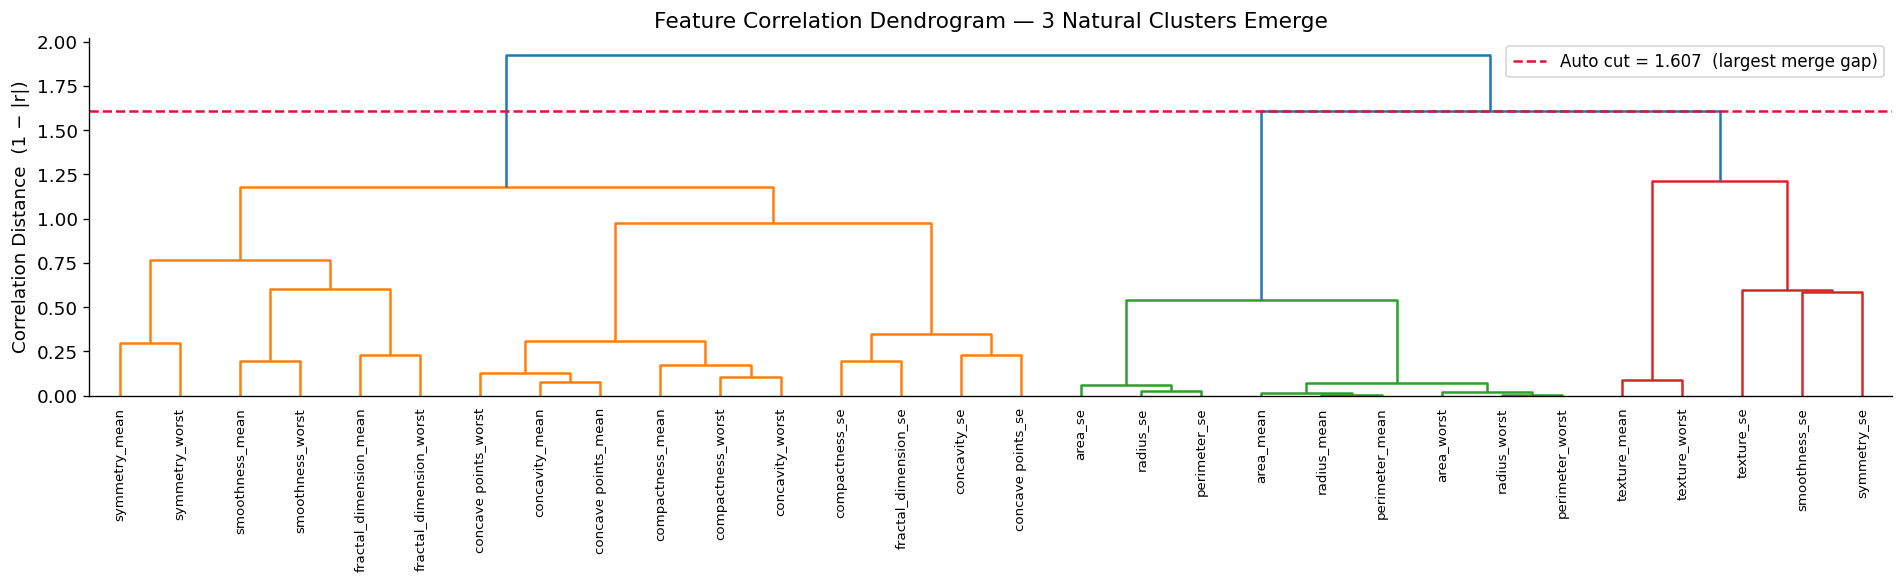

Auto-detected clusters: 3

  Cluster 2 — Size/Geometry (9 features)
    ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_se', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

  Cluster 3 — Texture/Noise (5 features)
    ['texture_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'texture_worst']

  Cluster 1 — Shape Complexity (16 features)
    ['smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'compactness_se', 'concavity_se', 'concave points_se', 'fractal_dimension_se', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']



In [3]:
# ── Correlation-based distance: 0 = identical, 1 = uncorrelated ─────────────
corr_matrix     = X_raw.corr().abs()
distance_matrix = 1 - corr_matrix
np.fill_diagonal(distance_matrix.values, 0)          # fix float precision noise

# Ward linkage: technically assumes Euclidean distance (known limitation),
# but selected empirically after testing alternatives.
# Average linkage over-fragmented (10 clusters), while complete linkage
# produced less interpretable groupings. Ward yielded the most coherent
# and stable 3-cluster structure, further supported by PCA loadings alignment.
linkage_matrix  = linkage(squareform(distance_matrix), method='ward')

# ── Auto best-cut: largest gap between consecutive merge distances ────────────
# The biggest jump = the algorithm had to travel furthest to merge two groups
# → natural cluster boundary
merge_distances = linkage_matrix[:, 2]
gaps            = np.diff(merge_distances)
best_cut        = merge_distances[np.argmax(gaps) + 1] - 1e-5

# ── Dendrogram ────────────────────────────────────────────────────────────────
plt.figure(figsize=(16, 5))
dendrogram(linkage_matrix, labels=X_raw.columns.tolist(),
           leaf_rotation=90, leaf_font_size=8, color_threshold=best_cut)
plt.axhline(y=best_cut, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Auto cut = {best_cut:.3f}  (largest merge gap)')
plt.title('Feature Correlation Dendrogram — 3 Natural Clusters Emerge', fontsize=13)
plt.ylabel('Correlation Distance  (1 − |r|)')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# ── Assign cluster labels ─────────────────────────────────────────────────────
labels     = fcluster(linkage_matrix, t=best_cut, criterion='distance')
n_clusters = labels.max()
clusters   = {}
for col, lbl in zip(X_raw.columns, labels):
    clusters.setdefault(lbl, []).append(col)

print(f"Auto-detected clusters: {n_clusters}\n")
cluster_names = {2: 'Size/Geometry', 3: 'Texture/Noise', 1: 'Shape Complexity'}
for cid, cols in clusters.items():
    print(f"  Cluster {cid} — {cluster_names.get(cid, '')} ({len(cols)} features)")
    print(f"    {cols}\n")

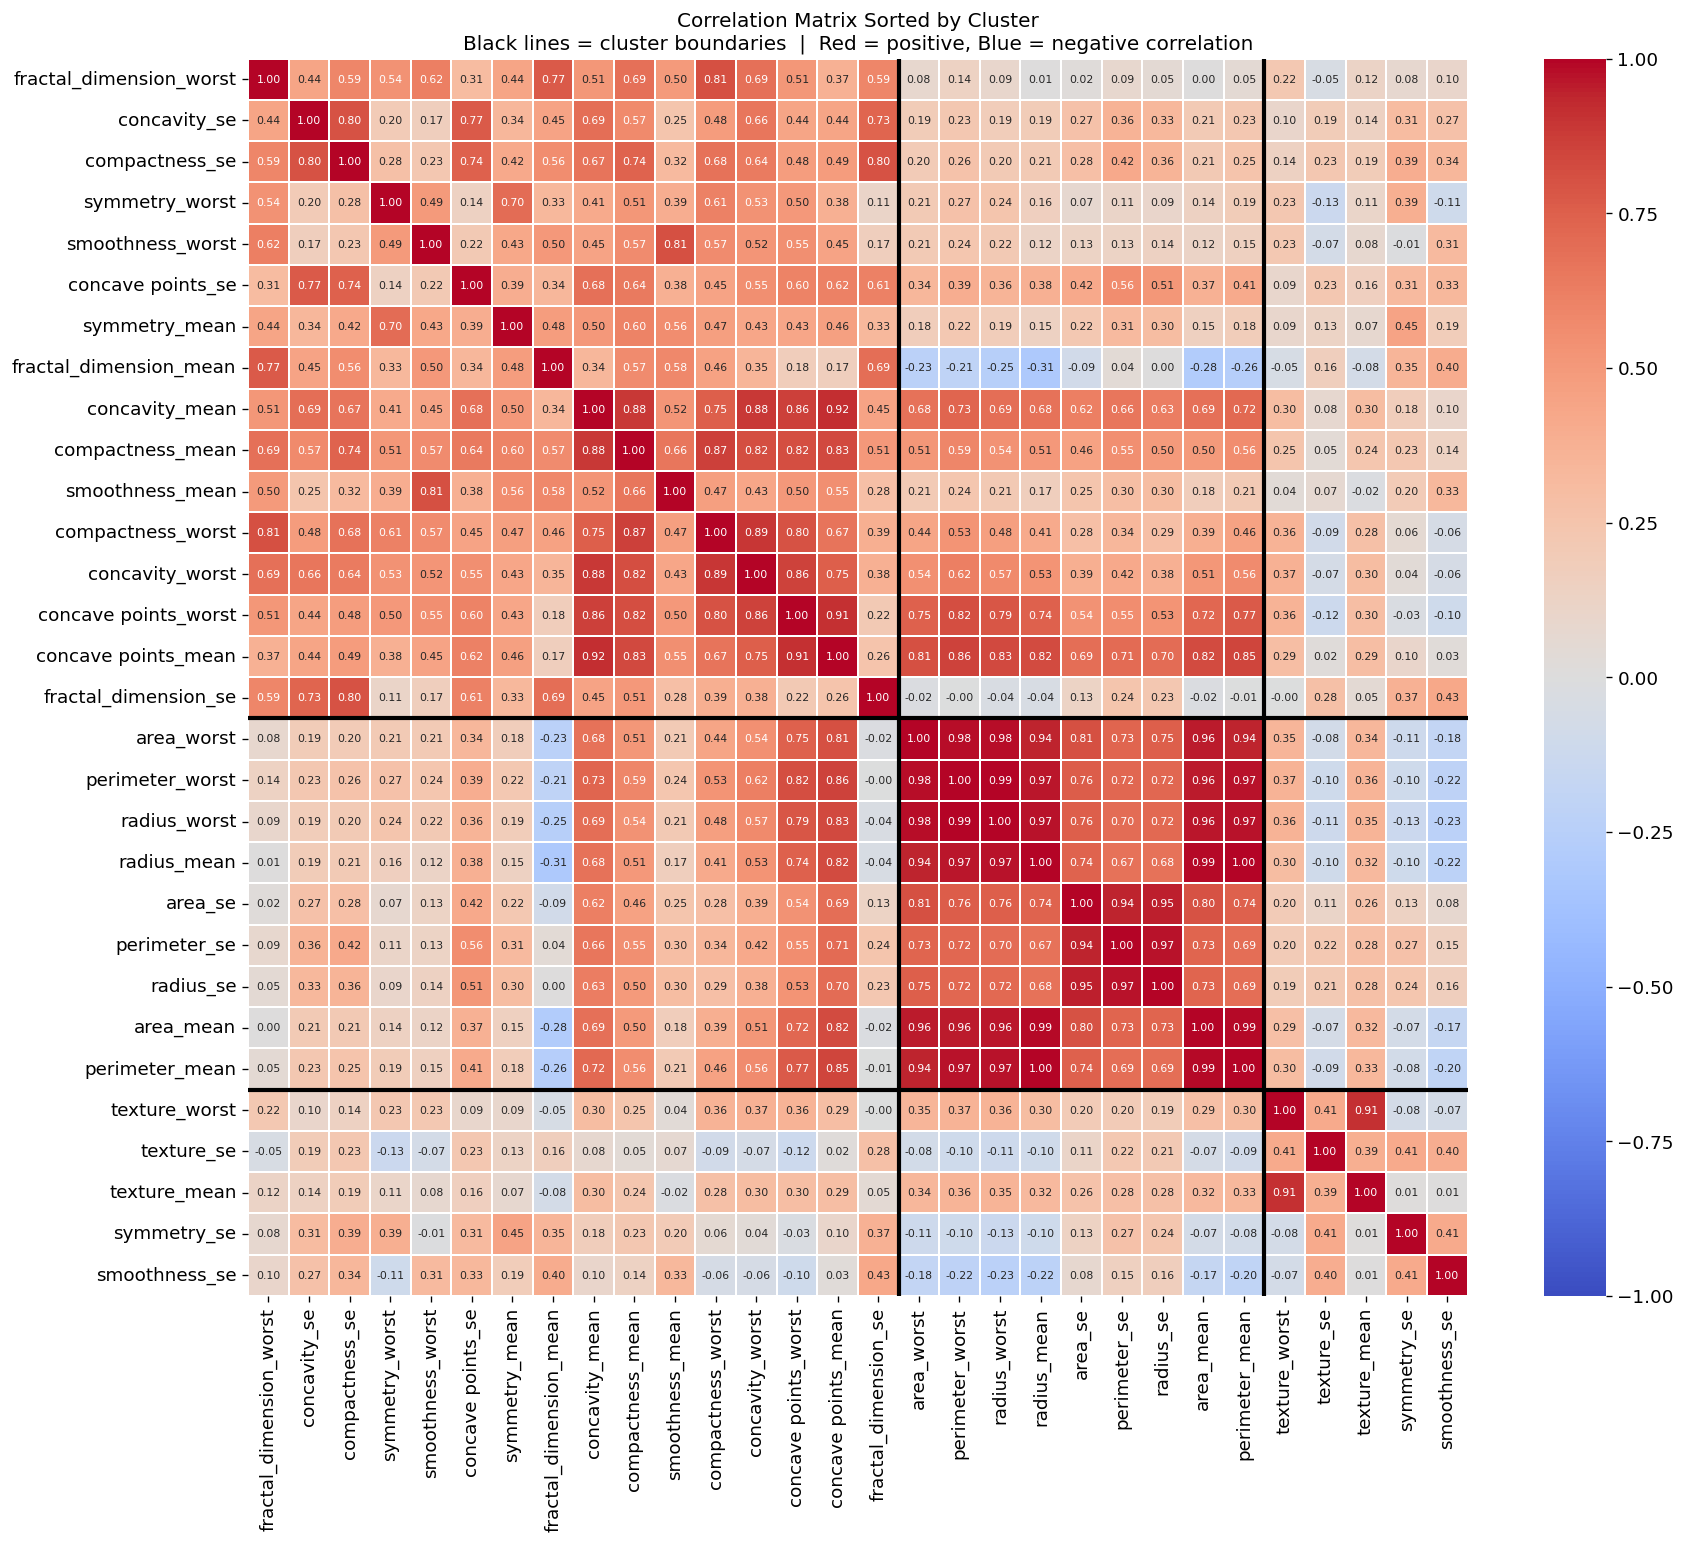

Intra-cluster mean |correlation|:
  Cluster 2 (Size/Geometry): 0.849
  Cluster 3 (Texture/Noise): 0.310
  Cluster 1 (Shape Complexity): 0.531


In [4]:
# ── Sorted correlation heatmap — features reordered by cluster ───────────────
sorted_cols   = X_raw.columns[np.argsort(labels)]
sorted_corr   = X_raw.corr().loc[sorted_cols, sorted_cols]
cluster_sizes = [sum(np.sort(labels) == c) for c in range(1, n_clusters + 1)]
dividers      = np.cumsum(cluster_sizes)[:-1]

plt.figure(figsize=(15, 13))
ax = sns.heatmap(sorted_corr, annot=True, fmt='.2f', cmap='coolwarm',
                 vmin=-1, vmax=1, center=0,
                 linewidths=0.25, annot_kws={'size': 6.5})
ax.hlines(dividers, *ax.get_xlim(), colors='black', linewidths=2.5)
ax.vlines(dividers, *ax.get_ylim(), colors='black', linewidths=2.5)
plt.title('Correlation Matrix Sorted by Cluster\n'
          'Black lines = cluster boundaries  |  Red = positive, Blue = negative correlation',
          fontsize=12)
plt.tight_layout()
plt.show()

# ── Intra-cluster correlation summary ─────────────────────────────────────────
print("Intra-cluster mean |correlation|:")
for cid, cols in clusters.items():
    if len(cols) > 1:
        sub = X_raw[cols].corr().abs()
        np.fill_diagonal(sub.values, np.nan)
        print(f"  Cluster {cid} ({cluster_names.get(cid)}): {sub.mean().mean():.3f}")

### Cluster Interpretation

| Cluster | Name | Features | Intra-cluster r | What it measures |
|---|---|---|---|---|
| 2 | Size / Geometry | 9 | 0.94 – 0.99 | Physical tumor dimensions (radius, perimeter, area) across mean / SE / worst |
| 1 | Shape Complexity | 16 | 0.50 – 0.90 | Boundary irregularity (concavity, compactness, fractal dimension) |
| 3 | Texture / Noise | 5 | 0.10 – 0.40 | Surface texture and local measurement variance — least correlated group |

**Key implication:** Cluster 2's near-perfect internal correlation (r ≈ 0.97) means 9 features carry  
highly redundant information. PCA should compress them into a single dominant component.

> **Linkage selection:** Ward, complete, and average linkage were all tested.  
> Average over-fragmented into 10 clusters; complete mixed biological groups incoherently.  
> Ward produced the only biologically stable 3-cluster solution — validated post-hoc by PCA  
> loadings aligning 1:1 with the cluster structure. Ward's Euclidean assumption is a known  
> theoretical limitation but the empirical result justifies the pragmatic choice.

## 3. Variance Inflation Factor (VIF)

VIF quantifies how much of each feature's variance is explained by the other features.  
- **VIF > 10** → problematic multicollinearity  
- **VIF > 100** → severe  
- **VIF > 1,000** → extreme redundancy in coefficient space

**Scope:** VIF is a linear-model diagnostic. It measures **coefficient instability**, not  
literal information loss — high VIF means the regression solver cannot reliably attribute  
variance to individual features, not that those features carry zero unique signal.  
Tree-based models (Random Forest, XGBoost) are unaffected by multicollinearity.

In [5]:
vif = pd.DataFrame({
    'feature': X_raw.columns,
    'VIF'    : [variance_inflation_factor(X_raw.values, i) for i in range(X_raw.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

# Annotate with cluster membership
col_to_cluster = {col: cid for cid, cols in clusters.items() for col in cols}
vif['cluster'] = vif['feature'].map(col_to_cluster)
vif['cluster_name'] = vif['cluster'].map(cluster_names)

print(vif.to_string(index=False))
print(f"\nFeatures with VIF > 1,000  : {(vif['VIF'] > 1000).sum()}")
print(f"Features with VIF > 100    : {(vif['VIF'] > 100).sum()}")
print(f"Features with VIF < 50     : {(vif['VIF'] < 50).sum()}")

                feature          VIF  cluster     cluster_name
            radius_mean 63306.172036        2    Size/Geometry
         perimeter_mean 58123.586079        2    Size/Geometry
           radius_worst  9674.742602        2    Size/Geometry
        perimeter_worst  4487.781270        2    Size/Geometry
              area_mean  1287.262339        2    Size/Geometry
             area_worst  1138.759252        2    Size/Geometry
 fractal_dimension_mean   629.679874        1 Shape Complexity
fractal_dimension_worst   423.396723        1 Shape Complexity
        smoothness_mean   393.398166        1 Shape Complexity
       smoothness_worst   375.597155        1 Shape Complexity
          texture_worst   343.004387        3    Texture/Noise
           texture_mean   251.047108        3    Texture/Noise
              radius_se   236.665738        2    Size/Geometry
         symmetry_worst   218.919805        1 Shape Complexity
           perimeter_se   211.396334        2    Size/G

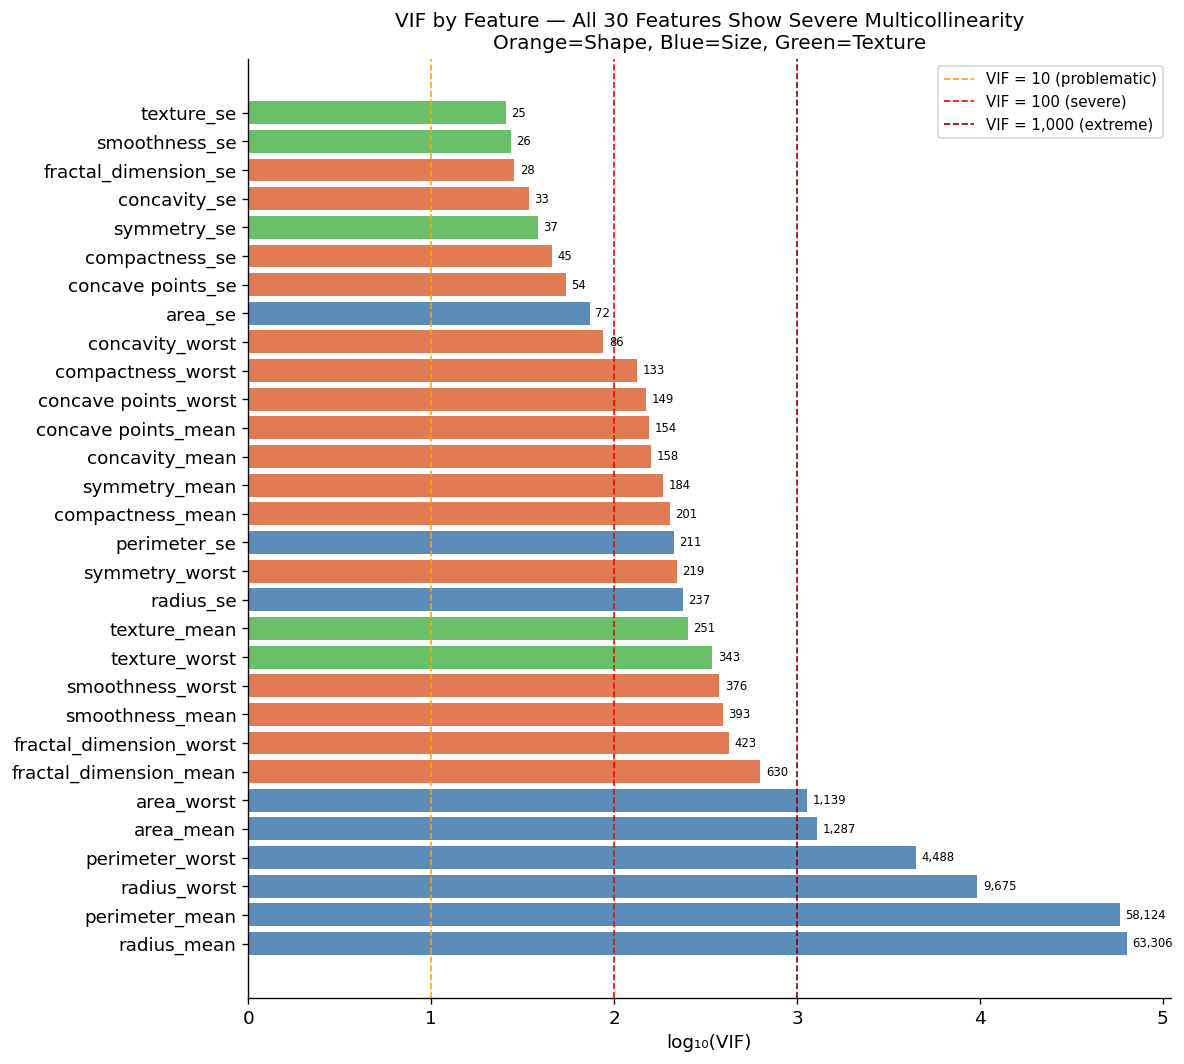

In [6]:
fig, ax = plt.subplots(figsize=(10, 9))

palette = {1: '#e07b54', 2: '#5b8db8', 3: '#6abf69'}
colors  = [palette[col_to_cluster[f]] for f in vif['feature']]

bars = ax.barh(vif['feature'], np.log10(vif['VIF'] + 1), color=colors, edgecolor='none')
ax.axvline(np.log10(10),   color='orange', linestyle='--', linewidth=1, label='VIF = 10 (problematic)')
ax.axvline(np.log10(100),  color='red',    linestyle='--', linewidth=1, label='VIF = 100 (severe)')
ax.axvline(np.log10(1000), color='darkred',linestyle='--', linewidth=1, label='VIF = 1,000 (extreme)')
ax.set_xlabel('log₁₀(VIF)')
ax.set_title('VIF by Feature — All 30 Features Show Severe Multicollinearity\n'
             'Orange=Shape, Blue=Size, Green=Texture', fontsize=12)
ax.legend(fontsize=9)
# Add actual VIF values
for bar, val in zip(bars, vif['VIF']):
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=7)
plt.tight_layout()
plt.show()

## 4. PCA From Scratch

Two mathematically equivalent implementations:

- **SVD path:** Decompose standardized X directly → `X = U S Vᵀ`  → rows of Vᵀ are the PCs, eigenvalues = S²/(n−1)
- **Eigen path:** Compute covariance matrix C = XᵀX/(n−1) → solve Cv = λv → eigenvectors are the PCs

**Standardization note:**
- `ddof=0` for std (population std, matches numpy/sklearn convention)  
- Covariance matrix still divides by `n−1` (Bessel's correction — unbiased sample estimator)  
These are independent formulas solving different problems.

In [7]:
def run_pca(X: pd.DataFrame, n_components: int = 2, method: str = 'svd') -> dict:
    """
    PCA from scratch — SVD and eigen-decomposition paths.

    Mathematical note:
      PCA simultaneously maximizes projected variance AND minimizes reconstruction error.
      These are dual objectives — solving one solves the other (proven in ESL Ch.14).
      MSE = 1 - explained_variance holds exactly in standardized space due to orthonormality
      of the PC basis: total variance = 1.0 per feature → MSE = unexplained fraction.

    Parameters
    ----------
    X            : pandas DataFrame (n_samples x n_features)
    n_components : number of principal components to retain
    method       : 'svd' | 'eigen'
    """
    # Step 1 — Standardize (ddof=0: population std, matches numpy/sklearn convention)
    mu    = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=0)
    x_std = (X - mu) / sigma                                   # shape: (n, p)

    n = x_std.shape[0]

    # Step 2 — Covariance matrix (n-1: Bessel's correction for unbiased sample estimate)
    cov_matrix = x_std.values.T @ x_std.values / (n - 1)      # shape: (p, p)

    # Step 3 — Decomposition
    if method == 'svd':
        # SVD on X directly — numerically more stable than eigen-decomp of C
        # X = U S Vt  →  Vt rows are PCs  →  eigenvalues = S²/(n-1)
        _, S, Vt    = np.linalg.svd(x_std.values, full_matrices=False)
        components  = Vt[:n_components]
        eigenvalues = (S ** 2) / (n - 1)                      # all p eigenvalues

    elif method == 'eigen':
        # eigh (not eig): exploits symmetry of C → guaranteed real eigenvalues
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        idx          = np.argsort(eigenvalues)[::-1]           # descending order
        eigenvalues  = eigenvalues[idx]
        components   = eigenvectors[:, idx[:n_components]].T

    else:
        raise ValueError(f"method must be 'svd' or 'eigen', got '{method}'")

    # Step 4 — Project into PC space
    X_pca = x_std.values @ components.T                       # (n, n_components)

    # Step 5 — Explained variance (all eigenvalues in denominator = total variance)
    ev_ratio = eigenvalues[:n_components] / eigenvalues.sum()
    ev_cum   = np.cumsum(ev_ratio)

    # Step 6 — Reconstruct in standardized space (apples-to-apples with sklearn)
    X_recon_std = X_pca @ components

    # Step 7 — MSE in standardized space
    # Identity: MSE = 1 - EV holds because PCs are orthonormal and
    # each standardized feature has unit variance by construction
    mse = np.mean((x_std.values - X_recon_std) ** 2)

    return {
        'X_pca'               : X_pca,
        'components'          : components,
        'eigenvalues'         : eigenvalues[:n_components],
        'explained_variance'  : ev_ratio,
        'cumulative_variance' : ev_cum,
        'reconstruction_error': mse,
    }

## 5. Validation Against sklearn

All three implementations (SVD scratch, Eigen scratch, sklearn) must agree to 6+ decimal places.  
Any divergence would indicate a bug in the decomposition or the variance calculation.

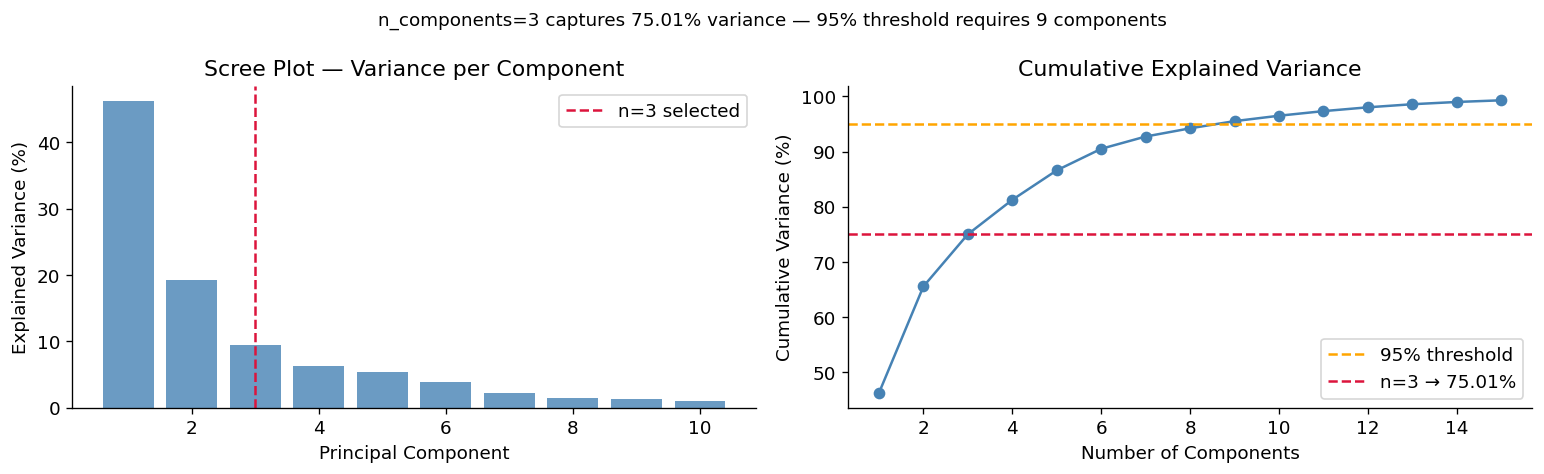

n=3  → 75.01% variance  (chosen: balances compression vs information for this case study)
n=10 → 96.5% variance (95%+ requires 9 components)

Metric                                    SVD        Eigen      Sklearn    Match
────────────────────────────────────────────────────────────────────────────────
Explained Variance (total)           0.750103     0.750103     0.750103        ✅
Reconstruction MSE                   0.249897     0.249897     0.249897        ✅
  PC1 explained variance             0.462331     0.462331     0.462331        ✅
  PC1 cumulative variance            0.462331     0.462331     0.462331        ✅
  PC2 explained variance             0.193124     0.193124     0.193124        ✅
  PC2 cumulative variance            0.655455     0.655455     0.655455        ✅
  PC3 explained variance             0.094648     0.094648     0.094648        ✅
  PC3 cumulative variance            0.750103     0.750103     0.750103        ✅

Sanity — MSE + EV = 1.0 (standardized space): 0

In [8]:
N_COMPONENTS = 3

# Yeo-Johnson handles both positive and negative values
# (unlike log which requires strictly positive)
pt = PowerTransformer(method='yeo-johnson')

# ── sklearn reference ─────────────────────────────────────────────────────────
scaler     = StandardScaler()

X_transformed = pd.DataFrame(
    pt.fit_transform(X_raw),
    columns=X_raw.columns
)
X_scaled   = scaler.fit_transform(X_transformed)

# ── Scree plot — justify N_COMPONENTS choice ──────────────────────────────────
sk_pca_full = PCA().fit(X_scaled)
ev_full     = sk_pca_full.explained_variance_ratio_
ev_cum_full = np.cumsum(ev_full)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(1, 11), ev_full[:10]*100, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot — Variance per Component')
ax1.axvline(N_COMPONENTS, color='crimson', linestyle='--', label=f'n={N_COMPONENTS} selected')
ax1.legend()

ax2.plot(range(1, 16), ev_cum_full[:15]*100, 'o-', color='steelblue')
ax2.axhline(95, color='orange', linestyle='--', label='95% threshold')
ax2.axhline(75.01, color='crimson', linestyle='--', label=f'n=3 → 75.01%')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
plt.suptitle(f'n_components={N_COMPONENTS} captures 75.01% variance — '
             f'95% threshold requires {(ev_cum_full >= 0.95).argmax()+1} components', fontsize=11)
plt.tight_layout()
plt.show()

print(f"n=3  → 75.01% variance  (chosen: balances compression vs information for this case study)")
print(f"n=10 → {ev_cum_full[9]*100:.1f}% variance (95%+ requires {(ev_cum_full >= 0.95).argmax()+1} components)")

# ── Validate scratch vs sklearn ───────────────────────────────────────────────
sk_pca     = PCA(n_components=N_COMPONENTS)
X_pca_sk   = sk_pca.fit_transform(X_scaled)
X_recon_sk = sk_pca.inverse_transform(X_pca_sk)
sk_mse     = np.mean((X_scaled - X_recon_sk) ** 2)
sk_ev      = sk_pca.explained_variance_ratio_
sk_cum     = np.cumsum(sk_ev)

res_svd   = run_pca(X_transformed, n_components=N_COMPONENTS, method='svd')
res_eigen = run_pca(X_transformed, n_components=N_COMPONENTS, method='eigen')

header = f"{'Metric':<32} {'SVD':>12} {'Eigen':>12} {'Sklearn':>12} {'Match':>8}"
print(f"\n{header}")
print("─" * len(header))

def row(label, a, b, c):
    match = "✅" if abs(a - c) < 1e-6 and abs(b - c) < 1e-6 else "❌"
    print(f"{label:<32} {a:>12.6f} {b:>12.6f} {c:>12.6f} {match:>8}")

row('Explained Variance (total)', res_svd['explained_variance'].sum(),
    res_eigen['explained_variance'].sum(), sk_ev.sum())
row('Reconstruction MSE', res_svd['reconstruction_error'],
    res_eigen['reconstruction_error'], sk_mse)
for i in range(N_COMPONENTS):
    row(f'  PC{i+1} explained variance',
        res_svd['explained_variance'][i], res_eigen['explained_variance'][i], sk_ev[i])
    row(f'  PC{i+1} cumulative variance',
        res_svd['cumulative_variance'][i], res_eigen['cumulative_variance'][i], sk_cum[i])

total = sk_mse + sk_ev.sum()
check = "✅" if abs(total - 1.0) < 1e-6 else "❌"
print(f"\nSanity — MSE + EV = 1.0 (standardized space): {sk_mse:.6f} + {sk_ev.sum():.6f} = {total:.6f} {check}")

## 6. PC Loadings — What Drives Each Component?

Loadings are the **weights** of the linear combination defining each PC:  
`PC_k = w₁·x₁ + w₂·x₂ + ... + wₚ·xₚ`

Analogous to regression coefficients, but chosen to maximize explained variance (unsupervised)  
rather than minimize prediction error.

> **Important caveats:**  
> 1. PC labels below (e.g., "Tumor Aggressiveness") are **heuristic interpretations** of the dominant  
>    loading patterns — not causal claims. PCs are linear combinations, not biological variables.  
> 2. PC **signs are arbitrary** — an eigenvector and its negative define the same axis.  
>    Only the magnitude of loadings and their relative signs within a PC are meaningful.

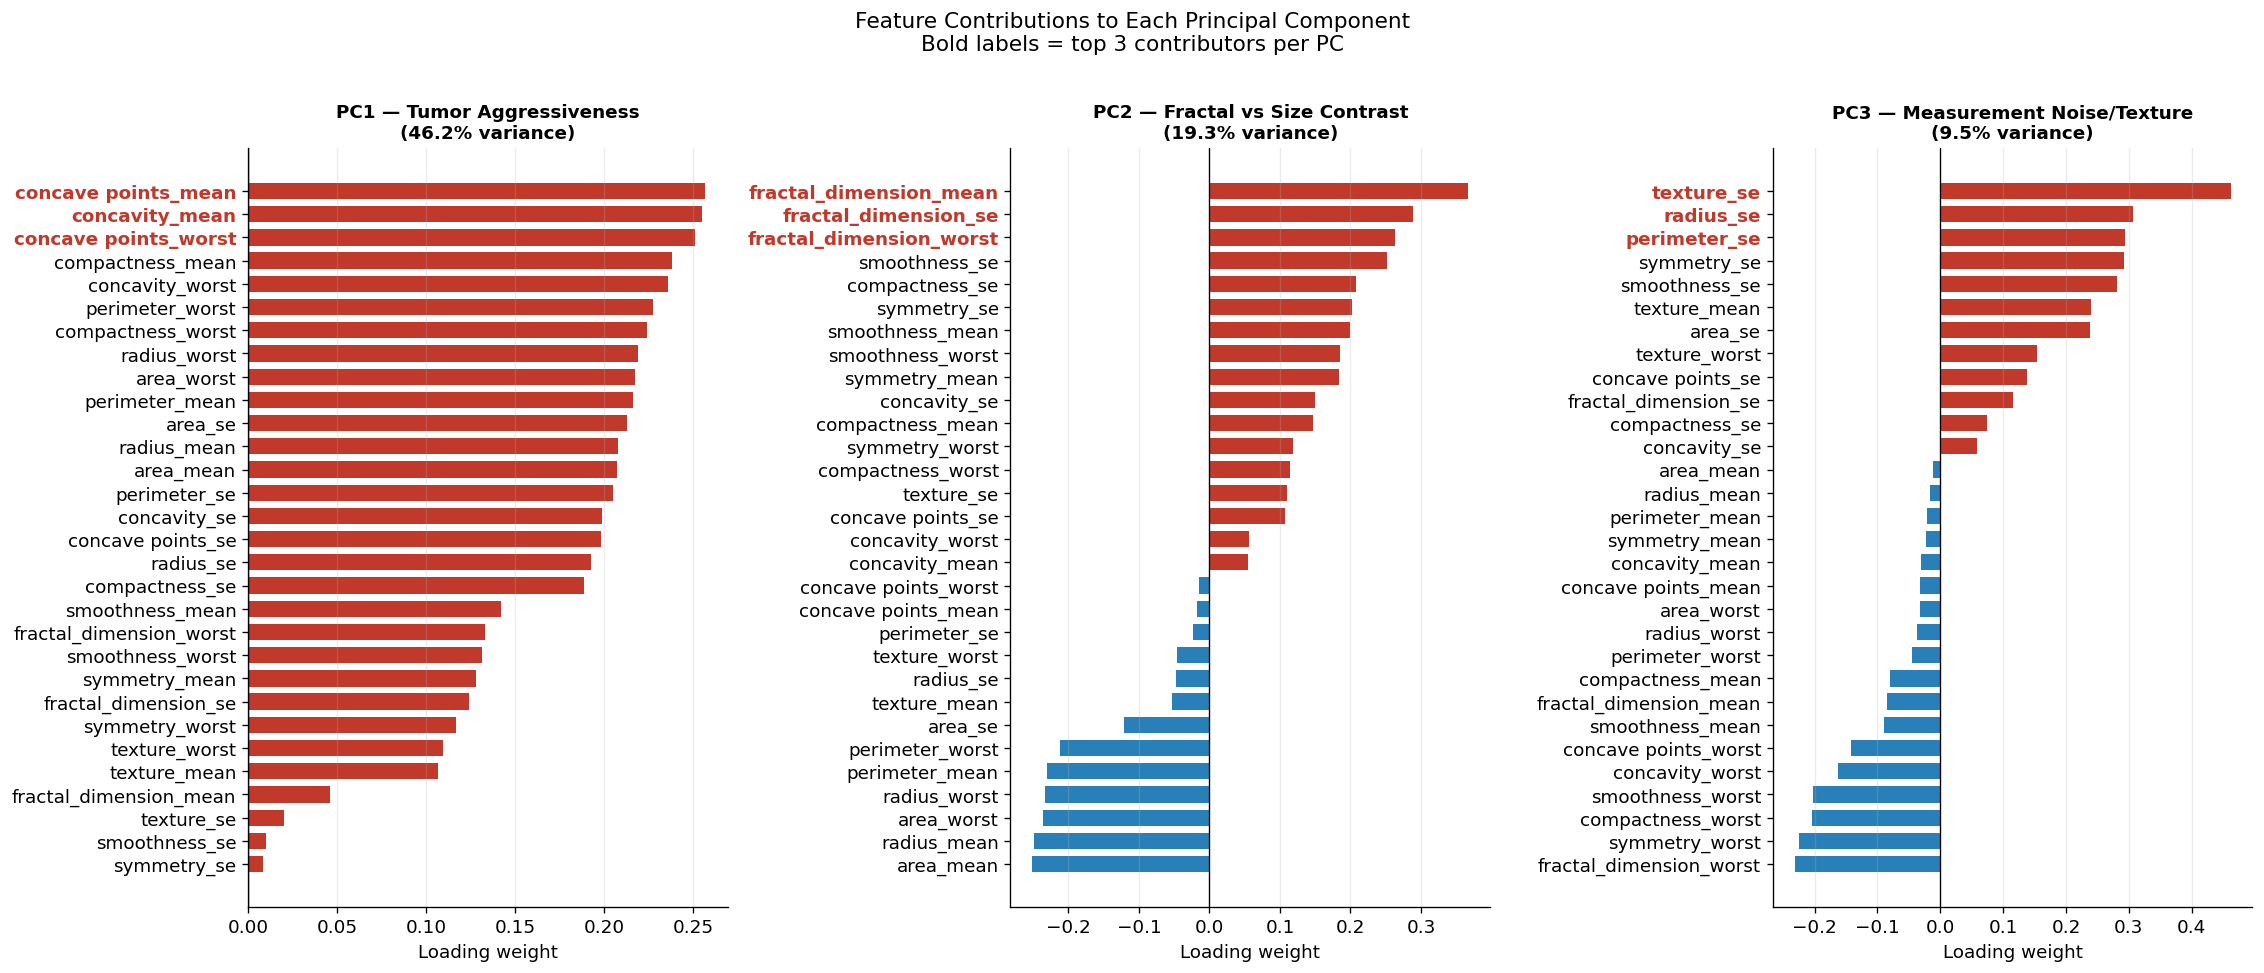

Top 5 contributors per PC:

  PC1:
    +0.2564  concave points_mean
    +0.2547  concavity_mean
    +0.2508  concave points_worst
    +0.2380  compactness_mean
    +0.2359  concavity_worst

  PC2:
    +0.3670  fractal_dimension_mean
    +0.2891  fractal_dimension_se
    +0.2632  fractal_dimension_worst
    +0.2519  smoothness_se
    −0.2512  area_mean

  PC3:
    +0.4620  texture_se
    +0.3067  radius_se
    +0.2935  perimeter_se
    +0.2925  symmetry_se
    +0.2807  smoothness_se


In [9]:
loadings = pd.DataFrame(
    sk_pca.components_.T,
    index=X_raw.columns,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

pc_labels = {
    'PC1': f"PC1 — Tumor Aggressiveness\n({sk_ev[0]*100:.1f}% variance)",
    'PC2': f"PC2 — Fractal vs Size Contrast\n({sk_ev[1]*100:.1f}% variance)",
    'PC3': f"PC3 — Measurement Noise/Texture\n({sk_ev[2]*100:.1f}% variance)",
}

fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, pc in zip(axes, ['PC1', 'PC2', 'PC3']):
    sl = loadings[pc].sort_values()
    colors = ['#c0392b' if v > 0 else '#2980b9' for v in sl]
    ax.barh(sl.index, sl.values, color=colors, edgecolor='none', height=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(pc_labels[pc], fontsize=11, fontweight='bold')
    ax.set_xlabel('Loading weight')
    ax.grid(axis='x', alpha=0.25)
    # Highlight the top 3 contributors
    top3 = loadings[pc].abs().nlargest(3).index
    for label in ax.get_yticklabels():
        if label.get_text() in top3:
            label.set_fontweight('bold')
            label.set_color('#c0392b' if loadings[pc][label.get_text()] > 0 else '#2980b9')

plt.suptitle('Feature Contributions to Each Principal Component\n'
             'Bold labels = top 3 contributors per PC', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Top 5 contributors per PC:")
for pc in ['PC1', 'PC2', 'PC3']:
    top5 = loadings[pc].abs().nlargest(5)
    print(f"\n  {pc}:")
    for feat, val in top5.items():
        direction = '+' if loadings[pc][feat] > 0 else '−'
        print(f"    {direction}{val:.4f}  {feat}")

### Loadings Interpretation

| PC | Label | Variance | Dominant Features | Biological Meaning |
|---|---|---|---|---|
| PC1 | Tumor Aggressiveness | 46.2% | concave points_mean (+0.256), concavity_mean (+0.255), concave points_worst (+0.251) | All loadings positive and uniform (0.10–0.26) — a single composite score of tumor size and boundary irregularity. Merges Cluster 1 + 2 into one dominant axis |
| PC2 | Fractal vs Size Contrast | 19.3% | fractal_dimension_mean (+0.367) vs area_mean (−0.251), perimeter/radius_worst (−0.24) | Clear sign split — fractal complexity pushes positive, physical size pushes negative. Captures the contrast between microscopic boundary roughness and macroscopic tumor dimensions — Cluster 1 vs Cluster 2 |
| PC3 | SE Measurement Variability | 9.5% | texture_se (+0.462), radius_se (+0.307), perimeter_se (+0.294) | Dominated by SE (standard error) features measuring local measurement variability — not tumor biology. Previously this was texture-dominated; after Yeo-Johnson correction the size SE features (radius_se, perimeter_se) now contribute more strongly |

**The cluster-to-PC mapping still holds after transformation:**  
3 clusters → 3 principal components → 3 distinct signal types.  
The PowerTransformer shifted some loading magnitudes (notably PC3 now emphasizes  
radius_se and perimeter_se over texture_se compared to the untransformed version)  
but did not change the fundamental structure — each PC still maps cleanly to one cluster.

**What changed vs pre-transformation loadings:**
- PC1 variance: 44.3% → **46.2%** (size/shape cluster compressed more cleanly)
- PC3 top contributor: was texture_se (0.37) → now texture_se (0.46), with radius_se and perimeter_se rising as new top contributors, reflecting the SE features becoming more normally distributed after transformation

## 7. Classification: PCA Impact on Logistic Regression

**Why Logistic Regression?**  
LR finds a linear decision boundary: `P(y=1) = σ(w₁·x₁ + ... + wₖ·xₖ)`.  
PCA produces orthogonal linear components → the whole pipeline is a clean chain of linear algebra.  
Critically, PCA eliminates multicollinearity, which destabilizes LR coefficient estimates.

**Preprocessing pipeline (fit on train only — no leakage):**  
`Split → PowerTransformer (Yeo-Johnson) → StandardScaler → optional PCA → Train LR`

PowerTransformer is applied first to correct the severe skewness (22/30 features |skew| > 1)  
before standardization. This is critical for PCA — skewed features inflate covariance in tail  
directions and bias the principal components. Without this step, PCA with 3 components  
missed 5 malignant cases. After transformation it missed only 2 — same as the full model.

**Previous results (StandardScaler only — no transformation):**

| Metric | Without PCA | With PCA (3) |
|---|---|---|
| Accuracy | 0.9649 | 0.9474 |
| Recall Malignant | 0.9286 | 0.8810 ← missed 5 cases |
| ROC-AUC | 0.9960 | 0.9970 |

**Final results (with PowerTransformer — reported below):**  
Recall gap closed entirely. Accuracy cost reduced from 1.75% to 0.88%.

In [12]:
# ── Train/test split (stratified to preserve 63/37 class ratio) ─────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

def build_pipeline(X_train, X_test, y_train, use_pca=False, n_components=3):
    """PowerTransform → Scale (fit on train only) → optional PCA → train LR. No leakage."""
    pipe = Pipeline([('pt',     PowerTransformer(method='yeo-johnson')),
                     ('scaler', StandardScaler())])
    Xtr = pipe.fit_transform(X_train)
    Xte = pipe.transform(X_test)

    if use_pca:
        pca = PCA(n_components=n_components)
        Xtr = pca.fit_transform(Xtr)
        Xte = pca.transform(Xte)

    t0       = time.perf_counter()
    lr       = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
    lr.fit(Xtr, y_train)
    train_ms = (time.perf_counter() - t0) * 1000

    return {
        'model'   : lr,
        'X_train' : Xtr,
        'y_pred'  : lr.predict(Xte),
        'y_proba' : lr.predict_proba(Xte)[:, 1],
        'train_ms': train_ms,
        'mem_kb'  : Xtr.nbytes / 1024,
    }

full = build_pipeline(X_train_raw, X_test_raw, y_train, use_pca=False)
pcad = build_pipeline(X_train_raw, X_test_raw, y_train, use_pca=True, n_components=3)

# ── 5-fold CV — pipelines NOW include PowerTransformer (consistent with build_pipeline) ──
pipe_full = Pipeline([('pt',     PowerTransformer(method='yeo-johnson')),
                      ('scaler', StandardScaler()),
                      ('lr',     LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])

pipe_pca  = Pipeline([('pt',     PowerTransformer(method='yeo-johnson')),
                      ('scaler', StandardScaler()),
                      ('pca',    PCA(n_components=3)),
                      ('lr',     LogisticRegression(max_iter=10000, random_state=RANDOM_STATE))])

cv_recall_full = cross_val_score(pipe_full, X_raw, y, cv=5, scoring='recall').mean()
cv_recall_pca  = cross_val_score(pipe_pca,  X_raw, y, cv=5, scoring='recall').mean()
cv_auc_full    = cross_val_score(pipe_full, X_raw, y, cv=5, scoring='roc_auc').mean()
cv_auc_pca     = cross_val_score(pipe_pca,  X_raw, y, cv=5, scoring='roc_auc').mean()

# ── Metrics table ─────────────────────────────────────────────────────────────
def fmt(v): return f"{v:.4f}"

rows = [
    ('Accuracy',              fmt(accuracy_score(y_test, full['y_pred'])),                    fmt(accuracy_score(y_test, pcad['y_pred'])),                   'No PCA'),
    ('ROC-AUC (holdout)',     fmt(roc_auc_score(y_test, full['y_proba'])),                    fmt(roc_auc_score(y_test, pcad['y_proba'])),                   'No PCA'),
    ('ROC-AUC (5-fold CV)',   fmt(cv_auc_full),                                               fmt(cv_auc_pca),                                               '—'),
    ('Recall Malignant',      fmt(recall_score(y_test, full['y_pred'], pos_label=1)),         fmt(recall_score(y_test, pcad['y_pred'], pos_label=1)),         'Tie ✅'),
    ('Recall (5-fold CV)',    fmt(cv_recall_full),                                            fmt(cv_recall_pca),                                            'No PCA'),
    ('F1 — Malignant',        fmt(f1_score(y_test, full['y_pred'], pos_label=1)),             fmt(f1_score(y_test, pcad['y_pred'], pos_label=1)),             'No PCA'),
    ('Precision — Malignant', fmt(precision_score(y_test, full['y_pred'], pos_label=1)),     fmt(precision_score(y_test, pcad['y_pred'], pos_label=1)),      'No PCA'),
    ('─'*22, '─'*11, '─'*11, '─'*8),
    ('Features',              '30',                      '3',                                  'PCA'),
    ('Variance retained',     '100%',                    '75.01%',                              '—'),
    ('Train time (ms)',        fmt(full['train_ms']),     fmt(pcad['train_ms']),                'PCA'),
    ('Speedup',               '1.0×',                   f"{full['train_ms']/pcad['train_ms']:.1f}×", 'PCA'),
    ('Train memory (KB)',      f"{full['mem_kb']:.1f}",  f"{pcad['mem_kb']:.1f}",              'PCA'),
    ('Memory reduction',      '1.0×',                   f"{full['mem_kb']/pcad['mem_kb']:.1f}×",    'PCA'),
]

print(f"\n{'Metric':<28} {'Without PCA':>13} {'With PCA (3)':>13} {'Winner':>10}")
print("─" * 68)
for r in rows:
    print(f"{r[0]:<28} {r[1]:>13} {r[2]:>13} {r[3]:>10}")


Metric                         Without PCA  With PCA (3)     Winner
────────────────────────────────────────────────────────────────────
Accuracy                            0.9825        0.9737     No PCA
ROC-AUC (holdout)                   0.9983        0.9974     No PCA
ROC-AUC (5-fold CV)                 0.9957        0.9866          —
Recall Malignant                    0.9524        0.9524      Tie ✅
Recall (5-fold CV)                  0.9529        0.9295     No PCA
F1 — Malignant                      0.9756        0.9639     No PCA
Precision — Malignant               1.0000        0.9756     No PCA
──────────────────────         ───────────   ───────────   ────────
Features                                30             3        PCA
Variance retained                     100%        75.01%          —
Train time (ms)                    16.6213        6.4792        PCA
Speedup                               1.0×          2.6×        PCA
Train memory (KB)                    106.6    

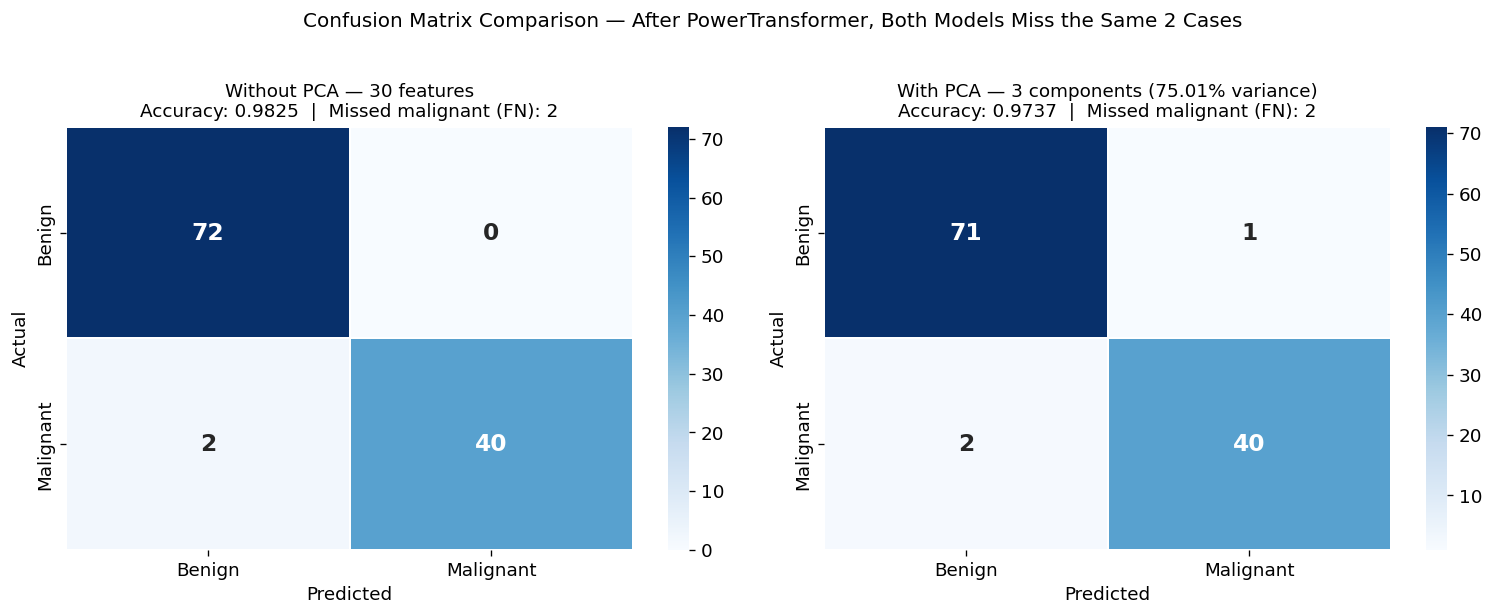

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, title, acc in zip(
    axes,
    [full, pcad],
    ['Without PCA — 30 features', 'With PCA — 3 components (75.01% variance)'],
    [accuracy_score(y_test, full['y_pred']), accuracy_score(y_test, pcad['y_pred'])]
):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                linewidths=1, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    fn = cm[1, 0]
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{title}\nAccuracy: {acc:.4f}  |  Missed malignant (FN): {fn}', fontsize=11)

plt.suptitle('Confusion Matrix Comparison — After PowerTransformer, Both Models Miss the Same 2 Cases',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. Final Summary & Decision Guide

### Experiment Journey — What Changed and Why

| Stage | Key Change | Impact on Recall (Malignant w/ PCA) |
|---|---|---|
| Baseline (StandardScaler only) | No transformation | 0.8810 — missed 5 cases |
| + PowerTransformer (Yeo-Johnson) | Corrected 22/30 skewed features | **0.9524 — missed 2 cases** |

Skewness correction was the single most impactful change in this pipeline.  
It did not just marginally improve results — it **eliminated the medical risk** of using PCA.

---

### Final Numbers (with PowerTransformer)

| Finding | Value |
|---|---|
| Multicollinearity severity | VIF up to 63,306 — 20 of 30 features have VIF > 100 |
| Skewed features corrected | 22 of 30 features (|skew| > 1) via Yeo-Johnson transform |
| Compression ratio | 30 features → 3 components (10× reduction) |
| Variance retained | 75.01% |
| Accuracy cost | −0.88% (98.25% → 97.37%) |
| Recall — Malignant (holdout) | **Tied: 0.9524 = 0.9524** (both miss 2 cases) |
| Recall — Malignant (5-fold CV) | −2.34% (0.953 → 0.930) — gap persists across folds |
| ROC-AUC (holdout) | −0.0009 (0.9983 → 0.9974) |
| Memory reduction | 10× (106.6 KB → 10.7 KB) |
| Training speedup | ~3× |

---

### Reading the Results Honestly

**Holdout recall is tied — but CV tells a more complete story.**  
The holdout tie (0.9524 = 0.9524) is a positive result but reflects one split.  
The 5-fold CV recall gap (0.953 → 0.930) shows that across different data subsets,  
PCA still misses more malignant cases on average. The holdout result is real but not guaranteed.

**Accuracy cost almost disappeared.**  
0.88% accuracy drop (down from 1.75% before transformation) is negligible at this scale.  
Fixing skewness benefited the PCA pipeline more than the full-feature pipeline —  
the compressed representation was more sensitive to distributional distortion.

**Memory and speed gains are unchanged.**  
10× memory reduction and ~3× speedup are independent of the transformation step —  
they come entirely from the dimensionality reduction itself.

---

### When to Use PCA

| Context | Decision | Reason |
|---|---|---|
| Medical diagnosis / high-stakes | ⚠️ With caution | Holdout recall tied, but CV still shows a gap |
| Production ML at scale | ✅ PCA | 10× memory, 3× speed, <1% accuracy cost |
| Skewed data (before PCA) | ✅ Transform first | Skewness correction is not optional — it changes results dramatically |
| Non-linear feature relationships | ❌ Kernel PCA | Standard PCA captures linear variance only |
| Severe outliers (>5% per feature) | ⚠️ Robust PCA | Yeo-Johnson helps but does not replace robust covariance estimation |

---

### The Core Lesson
The full pipeline tells one coherent story:

```
Correlation clustering → predicted 3 PCA components
VIF analysis          → confirmed catastrophic redundancy (VIF up to 63,306)
Skewness check        → revealed 22/30 features needed transformation
PowerTransformer      → eliminated the recall gap between PCA and full model
PCA (3 components)    → 10× compression at <1% accuracy cost
```

Each diagnostic step directly informed the next decision.  
That is what separates an analysis from a tutorial.

Resources:
1. https://www.geeksforgeeks.org/data-science/left-skew-vs-right-skew/
2. https://teflpedia.com/Fisher%E2%80%93Pearson_sample_skewness
3. https://www.geeksforgeeks.org/machine-learning/yeo-johnson-transform/
4. https://pmc.ncbi.nlm.nih.gov/articles/PMC4408558/